# Preamble

## Store Sales Dataset — EDA

This notebook is an exploratory data analysis (EDA) of a store's sales data (orders, products, customers, shipping, and returns).

**Main question of this analysis:**
There's a common belief that goes something like *"stores use discounts to trick people into buying more, and end up making more profit in the end."*
After preparing and exploring the data, this notebook tests that claim with formal statistical methods:

> Does putting a discount on an item cause a significant change in the **number of units sold (Quantity)**?

## Importations

In [88]:
import numpy as np
import pandas as pd
import math

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px

from scipy import stats
from scipy.stats import shapiro, normaltest, levene, mannwhitneyu, ttest_ind, spearmanr

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", font_scale=1.0)

### Data Loading

In [133]:
customer = pd.read_csv('Raw_Data/customer.csv')
order = pd.read_csv('Raw_Data/order.csv')
order_detail = pd.read_csv('Raw_Data/order_detail.csv')
product = pd.read_csv('Raw_Data/product.csv')
returned = pd.read_csv('Raw_Data/returned.csv')
shipping = pd.read_csv('Raw_Data/shipping.csv')

tables = {
    "customer": customer, "order": order, "order_detail": order_detail,
    "product": product, "returned": returned, "shipping": shipping
}

for name, t in tables.items():
    rows, cols = t.shape
    print(f"{name:<15} | Shape: {rows:<6} rows, {cols:<3} columns")

customer        | Shape: 1589   rows, 3   columns
order           | Shape: 25033  rows, 5   columns
order_detail    | Shape: 49670  rows, 8   columns
product         | Shape: 10246  rows, 4   columns
returned        | Shape: 1172   rows, 1   columns
shipping        | Shape: 25033  rows, 8   columns


#### First look at the data

In [7]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1589 entries, 0 to 1588
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Customer ID    1589 non-null   object
 1   Customer Name  1589 non-null   object
 2   Segment        1589 non-null   object
dtypes: object(3)
memory usage: 37.4+ KB


In [9]:
order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25033 entries, 0 to 25032
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Order ID        25033 non-null  object
 1   Customer ID     25033 non-null  object
 2   Order Priority  25033 non-null  object
 3   Order Date      25033 non-null  object
 4   Market          25033 non-null  object
dtypes: object(5)
memory usage: 978.0+ KB


In [11]:
order_detail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49670 entries, 0 to 49669
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         49670 non-null  int64  
 1   Order ID       49670 non-null  object 
 2   Product ID     49670 non-null  object 
 3   Sales          49670 non-null  float64
 4   Quantity       49670 non-null  int64  
 5   Discount       49670 non-null  float64
 6   Profit         49670 non-null  float64
 7   Shipping Cost  49670 non-null  float64
dtypes: float64(4), int64(2), object(2)
memory usage: 3.0+ MB


In [13]:
product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10246 entries, 0 to 10245
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Product ID    10246 non-null  object
 1   Product Name  10246 non-null  object
 2   Category      10246 non-null  object
 3   Sub-Category  10246 non-null  object
dtypes: object(4)
memory usage: 320.3+ KB


In [15]:
returned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1172 entries, 0 to 1171
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Order ID  1172 non-null   object
dtypes: object(1)
memory usage: 9.3+ KB


In [17]:
shipping.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25033 entries, 0 to 25032
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Shipping ID  25033 non-null  int64 
 1   Order ID     25033 non-null  object
 2   Ship Date    25033 non-null  object
 3   Ship Mode    25033 non-null  object
 4   City         25033 non-null  object
 5   State        25033 non-null  object
 6   Country      25033 non-null  object
 7   Region       25033 non-null  object
dtypes: int64(1), object(7)
memory usage: 1.5+ MB


In [19]:
customer.head()

,Customer ID,Customer Name,Segment
0,AA-10315,Alex Avila,Consumer
1,AA-10375,Allen Armold,Consumer
2,AA-10480,Andrew Allen,Consumer
3,AA-10645,Anna Andreadi,Consumer
4,AA-315,Alex Avila,Consumer


In [21]:
order.head()

,Order ID,Customer ID,Order Priority,Order Date,Market
0,AE-2011-9160,PO-8865,Medium,2011-10-03 00:00:00,EMEA
1,AE-2013-1130,EB-4110,High,2013-10-14 00:00:00,EMEA
2,AE-2013-1530,MY-7380,High,2013-12-31 00:00:00,EMEA
3,AE-2014-2840,PG-8820,Critical,2014-11-05 00:00:00,EMEA
4,AE-2014-3830,GH-4665,Medium,2014-12-13 00:00:00,EMEA


In [23]:
order_detail.head()

,Row ID,Order ID,Product ID,Sales,Quantity,Discount,Profit,Shipping Cost
0,1,MX-2014-143658,OFF-LA-10002782,13.08,3,0.0,4.56,1.033
1,2,MX-2012-155047,FUR-FU-10004015,252.16,8,0.0,90.72,13.449
2,3,MX-2012-155047,FUR-BO-10002352,193.28,2,0.0,54.08,9.627
3,4,MX-2012-155047,OFF-BI-10004428,35.44,4,0.0,4.96,1.371
4,5,MX-2012-155047,OFF-AR-10004594,71.60,2,0.0,11.44,3.787


In [25]:
product.head()

,Product ID,Product Name,Category,Sub-Category
0,FUR-ADV-10000002,"Advantus Photo Frame, Duo Pack",Furniture,Furnishings
1,FUR-ADV-10000108,"Advantus Clock, Erganomic",Furniture,Furnishings
2,FUR-ADV-10000183,"Advantus Photo Frame, Black",Furniture,Furnishings
3,FUR-ADV-10000188,"Advantus Stacking Tray, Erganomic",Furniture,Furnishings
4,FUR-ADV-10000190,"Advantus Frame, Duo Pack",Furniture,Furnishings


In [27]:
returned.head()

,Order ID
0,CA-2011-100762
1,CA-2011-100867
2,CA-2011-102652
3,CA-2011-103373
4,CA-2011-103744


In [29]:
shipping.head()

,Shipping ID,Order ID,Ship Date,Ship Mode,City,State,Country,Region
0,21043,CA-2012-124891,2012-07-31 00:00:00,Same Day,New York City,New York,United States,East
1,21044,IN-2013-77878,2013-02-07 00:00:00,Second Class,Wollongong,New South Wales,Australia,Oceania
2,21045,IN-2013-71249,2013-10-18 00:00:00,First Class,Brisbane,Queensland,Australia,Oceania
3,21046,ES-2013-1579342,2013-01-30 00:00:00,First Class,Berlin,Berlin,Germany,Central
4,21047,SG-2013-4320,2013-11-06 00:00:00,Same Day,Dakar,Dakar,Senegal,Africa


In [31]:
customer.describe()

,Customer ID,Customer Name,Segment
count,1589,1589,1589
unique,1589,795,3
top,AA-10315,Alex Avila,Consumer
freq,1,2,817


In [33]:
order.describe()

,Order ID,Customer ID,Order Priority,Order Date,Market
count,25033,25033,25033,25033,25033
unique,25033,1589,4,1428,7
top,AE-2011-9160,PO-18850,Medium,2014-11-25 00:00:00,APAC
freq,1,41,14344,59,5437


In [35]:
order_detail.describe()

,Row ID,Sales,Quantity,Discount,Profit,Shipping Cost
count,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000
mean,25763.380974,243.840355,3.470787,0.143070,28.392264,26.041125
std,14838.084164,485.963091,2.274854,0.212046,172.399520,56.870281
min,1.000000,0.444000,1.000000,0.000000,-6599.980000,0.002000
25%,12749.250000,30.384000,2.000000,0.000000,0.000000,2.580000
50%,26073.500000,83.970000,3.000000,0.000000,9.154000,7.660000
75%,38522.750000,247.830000,5.000000,0.200000,36.266400,23.969000
max,51290.000000,22638.500000,14.000000,0.850000,8399.980000,933.570000


In [37]:
product.describe()

,Product ID,Product Name,Category,Sub-Category
count,10246,10246,10246,10246
unique,10246,3662,3,17
top,FUR-ADV-10000002,Staples,Office Supplies,Paper
freq,1,45,5674,779


In [39]:
returned.describe()

,Order ID
count,1172
unique,1172
top,CA-2011-100762
freq,1


In [41]:
shipping.describe(include='all')

,Shipping ID,Order ID,Ship Date,Ship Mode,City,State,Country,Region
count,25033.00000,25033,25033,25033,25033,25033,25033,25033
unique,NaN,25033,1464,4,3590,1089,147,13
top,NaN,CA-2012-124891,2014-11-17 00:00:00,Standard Class,New York City,California,United States,Central
freq,NaN,1,54,15011,448,1016,4990,5238
mean,33559.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,7226.54898,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,21043.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,27301.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,33559.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,39817.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Preprocessing

In [141]:
returned["Returned"] = 1

In [151]:
df = order_detail.merge(order, on="Order ID", how="left")
df = df.merge(product, on="Product ID", how="left")
df = df.merge(customer, on="Customer ID", how="left")
df = df.merge(shipping, on="Order ID", how="left")
df = df.merge(returned , on="Order ID" , how="left")
df.shape

(49670, 25)

In [153]:
df.head()

,Row ID,Order ID,Product ID,Sales,Quantity,Discount,Profit,Shipping Cost,Customer ID,Order Priority,...,Customer Name,Segment,Shipping ID,Ship Date,Ship Mode,City,State,Country,Region,Returned
0,1,MX-2014-143658,OFF-LA-10002782,13.08,3,0.0,4.56,1.033,SC-20575,Medium,...,Sonia Cooley,Consumer,44634,2014-10-06 00:00:00,Standard Class,Mexico City,Distrito Federal,Mexico,North,NaN
1,2,MX-2012-155047,FUR-FU-10004015,252.16,8,0.0,90.72,13.449,KW-16570,Medium,...,Kelly Williams,Consumer,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,NaN
2,3,MX-2012-155047,FUR-BO-10002352,193.28,2,0.0,54.08,9.627,KW-16570,Medium,...,Kelly Williams,Consumer,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,NaN
3,4,MX-2012-155047,OFF-BI-10004428,35.44,4,0.0,4.96,1.371,KW-16570,Medium,...,Kelly Williams,Consumer,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,NaN
4,5,MX-2012-155047,OFF-AR-10004594,71.60,2,0.0,11.44,3.787,KW-16570,Medium,...,Kelly Williams,Consumer,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,NaN


In [149]:
df['Row ID'].nunique() == len(df) 

True

In [51]:
df.drop(columns="Row ID" , inplace=True)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49670 entries, 0 to 49669
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        49670 non-null  object 
 1   Product ID      49670 non-null  object 
 2   Sales           49670 non-null  float64
 3   Quantity        49670 non-null  int64  
 4   Discount        49670 non-null  float64
 5   Profit          49670 non-null  float64
 6   Shipping Cost   49670 non-null  float64
 7   Customer ID     49670 non-null  object 
 8   Order Priority  49670 non-null  object 
 9   Order Date      49670 non-null  object 
 10  Market          49670 non-null  object 
 11  Product Name    49670 non-null  object 
 12  Category        49670 non-null  object 
 13  Sub-Category    49670 non-null  object 
 14  Customer Name   49670 non-null  object 
 15  Segment         49670 non-null  object 
 16  Shipping ID     49670 non-null  int64  
 17  Ship Date       49670 non-null 

In [55]:
df["Returned"] = df["Returned"].fillna(0)

In [57]:
df.describe()

,Sales,Quantity,Discount,Profit,Shipping Cost,Shipping ID,Returned
count,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000
mean,243.840355,3.470787,0.143070,28.392264,26.041125,31632.081639,0.059996
std,485.963091,2.274854,0.212046,172.399520,56.870281,6964.662856,0.237482
min,0.444000,1.000000,0.000000,-6599.980000,0.002000,21043.000000,0.000000
25%,30.384000,2.000000,0.000000,0.000000,2.580000,25564.000000,0.000000
50%,83.970000,3.000000,0.000000,9.154000,7.660000,30862.000000,0.000000
75%,247.830000,5.000000,0.200000,36.266400,23.969000,37182.750000,0.000000
max,22638.500000,14.000000,0.850000,8399.980000,933.570000,46075.000000,1.000000


### Dtype optimization

In [59]:
df = df.astype({
    "Quantity": "int8",
    "Shipping ID": "int32",
    "Sales": "float32",
    "Discount": "float32",
    "Profit": "float32",
    "Shipping Cost": "float32",
    "Returned": "int8",
})

In [61]:
category_dict = {
    "Order Priority": "category",
    "Market": "category",
    "Category": "category",
    "Sub-Category": "category",
    "Segment": "category",
    "Ship Mode": "category",
    "City": "category",
    "State": "category",
    "Country": "category",
    "Region": "category",
}

df = df.astype(category_dict)

In [63]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49670 entries, 0 to 49669
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        49670 non-null  object        
 1   Product ID      49670 non-null  object        
 2   Sales           49670 non-null  float32       
 3   Quantity        49670 non-null  int8          
 4   Discount        49670 non-null  float32       
 5   Profit          49670 non-null  float32       
 6   Shipping Cost   49670 non-null  float32       
 7   Customer ID     49670 non-null  object        
 8   Order Priority  49670 non-null  category      
 9   Order Date      49670 non-null  datetime64[ns]
 10  Market          49670 non-null  category      
 11  Product Name    49670 non-null  object        
 12  Category        49670 non-null  category      
 13  Sub-Category    49670 non-null  category      
 14  Customer Name   49670 non-null  object        
 15  Se

In [67]:
numeric_columns = ['Sales' , 'Quantity' , 'Discount' , 'Profit' , 'Shipping Cost']

In [69]:
categorical_columns = ["Order Priority" ,
"Market" , 
"Category" , 
"Sub-Category" ,
"Segment" , 
"Ship Mode" ,
"City" , 
"State" , 
"Country" , 
"Region" ,
"Returned", ]

## Duplicates

In [71]:
df.duplicated().sum()

0

## Nan

In [74]:
def nan_percentage(df: pd.DataFrame) -> pd.DataFrame:
    total_rows = len(df)
    missing_count = [df[col].isna().sum() for col in df.columns]
    nan_pct = [(df[col].isna().sum() / total_rows) * 100 for col in df.columns]
    result = pd.DataFrame({"Missing Count": missing_count, "Nan Percent": nan_pct}, index=df.columns)
    return result.sort_values(by="Nan Percent", ascending=False)

In [76]:
nan_percentage(df)

,Missing Count,Nan Percent
Order ID,0,0.0
Product ID,0,0.0
Region,0,0.0
Country,0,0.0
State,0,0.0
City,0,0.0
Ship Mode,0,0.0
Ship Date,0,0.0
Shipping ID,0,0.0
Segment,0,0.0


## Outliers

In [78]:
def outlier_detector(col, method="iqr", k=1.5, z_thresh=3, clip=False) -> pd.Series:
    col = col.replace([np.inf, -np.inf], np.nan)

    if method == "iqr":
        q1, q3 = col.quantile(0.25), col.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - k * iqr
        upper = q3 + k * iqr
        mask = (col < lower) | (col > upper)
        if clip:
            return col.clip(lower, upper)
        return mask

    elif method == "zscore":
        z = col.sub(col.mean()).div(col.std()).abs()
        mask = z > z_thresh
        if clip:
            mean, std = col.mean(), col.std()
            return col.clip(mean - z_thresh * std, mean + z_thresh * std)
        return mask

    raise ValueError("method must be 'iqr' or 'zscore'")

In [80]:
for c in numeric_columns:
    n_out = int(outlier_detector(df[c]).sum())
    pct = n_out / len(df) * 100
    print(f"{c:<15} -> {n_out:>6} outliers  ({pct:.2f}%)")

Sales           ->   5466 outliers  (11.00%)
Quantity        ->    847 outliers  (1.71%)
Discount        ->   3981 outliers  (8.01%)
Profit          ->   9448 outliers  (19.02%)
Shipping Cost   ->   5744 outliers  (11.56%)


`Sales`, `Profit`, and `Shipping Cost` have a noticeable share of outliers (by the IQR rule) — expected, since these columns are heavily right-skewed (a handful of very large orders alongside many small ones). These values are not removed, since they're a genuine part of sales behavior; a log scale is used in the plots to see them more clearly instead.

## Normality

In [82]:
def normality_checker(df, columns=None, alpha=0.05) -> pd.DataFrame:
    
    if columns is None:
        columns = df.select_dtypes(include='number').columns
    
    results = []
    
    for col in columns:
        clean_data = df[col].dropna()
        n = len(clean_data)
        
        if n < 3:
            results.append([col, n, None, "Not enough data"])
            continue
        
        stat, p_value = normaltest(clean_data)
        
        result = "Normal" if p_value > alpha else "Not normal"
        
        results.append([col, n, p_value, result])
    
    result_df = pd.DataFrame(
        results,
        columns=["Column", "Sample Size", "p-value", "Result"]
    )
    
    return result_df

In [84]:
normality_checker(df)

,Column,Sample Size,p-value,Result
0,Sales,49670,0.0,Not normal
1,Quantity,49670,0.0,Not normal
2,Discount,49670,0.0,Not normal
3,Profit,49670,0.0,Not normal
4,Shipping Cost,49670,0.0,Not normal
5,Shipping ID,49670,0.0,Not normal
6,Returned,49670,0.0,Not normal


None of the numeric variables are normal (expected — `Sales`/`Profit`/`Shipping Cost` are heavily right-skewed, and `Quantity`/`Discount` aren't really continuous to begin with). This means group comparisons later should use non-parametric tests (like Mann-Whitney U) instead of a plain t-test.

## Visualization

In [90]:
Blue = "#7B9FF9"
Orange = "#F7A98B"
FALLBACK_PALETTE = ["#7B9FF9", "#F7A98B", "#87A16A", "#DAB552", "#C0A2D4", "#66BB87"]

base = cm.get_cmap("coolwarm")
_colors = base(np.linspace(0.20, 0.80, 256))
soft_coolwarm = mcolors.LinearSegmentedColormap.from_list("soft_coolwarm", _colors)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_30232\958372145.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  base = cm.get_cmap("coolwarm")


In [92]:
def plot_numeric_overview(df, numeric_cols, k=1.5):
    n = len(numeric_cols)
    fig, axes = plt.subplots(n, 2, figsize=(12, 3.8 * n))
    if n == 1:
        axes = np.array([axes])

    for i, col in enumerate(numeric_cols):
        clean = df[col].replace([np.inf, -np.inf], np.nan).dropna()
        q1, q3 = clean.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - k * iqr, q3 + k * iqr
        n_lower, n_upper = (clean < lower).sum(), (clean > upper).sum()

        sns.boxplot(x=clean, ax=axes[i, 0], color=Blue, fliersize=3)
        axes[i, 0].set_title(f"{col} - Boxplot (lower: {n_lower}, upper: {n_upper})", fontsize=10)

        sns.histplot(clean, kde=True, ax=axes[i, 1], color=Blue, edgecolor="white")
        axes[i, 1].axvline(clean.mean(), color="red", linestyle="--", label="mean")
        axes[i, 1].axvline(clean.median(), color="green", linestyle="--", label="median")
        axes[i, 1].set_title(f"{col} - Histogram", fontsize=10)
        axes[i, 1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()


In [96]:
def plot_categorical_overview(df, categorical_cols, ncols=3, top_n=8):
    n = len(categorical_cols)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(categorical_cols):
        ax = axes[i]
        counts = df[col].value_counts(dropna=False)
        if len(counts) > top_n:
            top = counts.iloc[:top_n]
            other = pd.Series({"Other": counts.iloc[top_n:].sum()})
            counts = pd.concat([top, other])
        ax.pie(counts, labels=counts.index, autopct="%1.0f%%",
               colors=FALLBACK_PALETTE * (len(counts) // len(FALLBACK_PALETTE) + 1))
        ax.set_title(col, fontsize=11, fontweight="bold")

    for ax in axes[len(categorical_cols):]:
        fig.delaxes(ax)

    plt.tight_layout()
    plt.show()

In [242]:
TARGET_PALETTE = {"Discounted": Orange, "No Discount": Blue}

def numeric_vs_categorical_plot(df, col, target, bins=40):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    fig.suptitle(f"{col} by {target}", fontsize=14, fontweight="bold")

    target_values = sorted(df[target].dropna().unique())
    palette = {v: TARGET_PALETTE.get(v, FALLBACK_PALETTE[i]) for i, v in enumerate(target_values)}

    is_discrete = pd.api.types.is_integer_dtype(df[col]) and df[col].nunique() <= 20

    if is_discrete:
        hist_kwargs = {"discrete": True}
    else:
        lo, hi = df[col].quantile([0.01, 0.99])
        hist_kwargs = {"bins": bins, "binrange": (lo, hi)}

    sns.histplot(data=df, x=col, hue=target, multiple="dodge", stat="density",
                 common_norm=False, palette=palette, ax=axes[0], **hist_kwargs)
    axes[0].set_title("Distribution (density)")

    sns.histplot(data=df, x=col, hue=target, multiple="fill", palette=palette, ax=axes[1], **hist_kwargs)
    axes[1].set_title("Proportion")

    sns.boxplot(data=df, x=target, y=col, palette=palette, ax=axes[2])
    axes[2].set_title("Boxplot")

    if not is_discrete:
        axes[0].set_xlim(lo, hi)
        axes[1].set_xlim(lo, hi)

    plt.tight_layout()
    plt.show()

In [244]:
def corr_heatmap(numeric_df, method="spearman"):
    cor = numeric_df.corr(method=method)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cor, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0)
    plt.title(f"Correlation Heatmap ({method})")
    plt.tight_layout()
    plt.show()

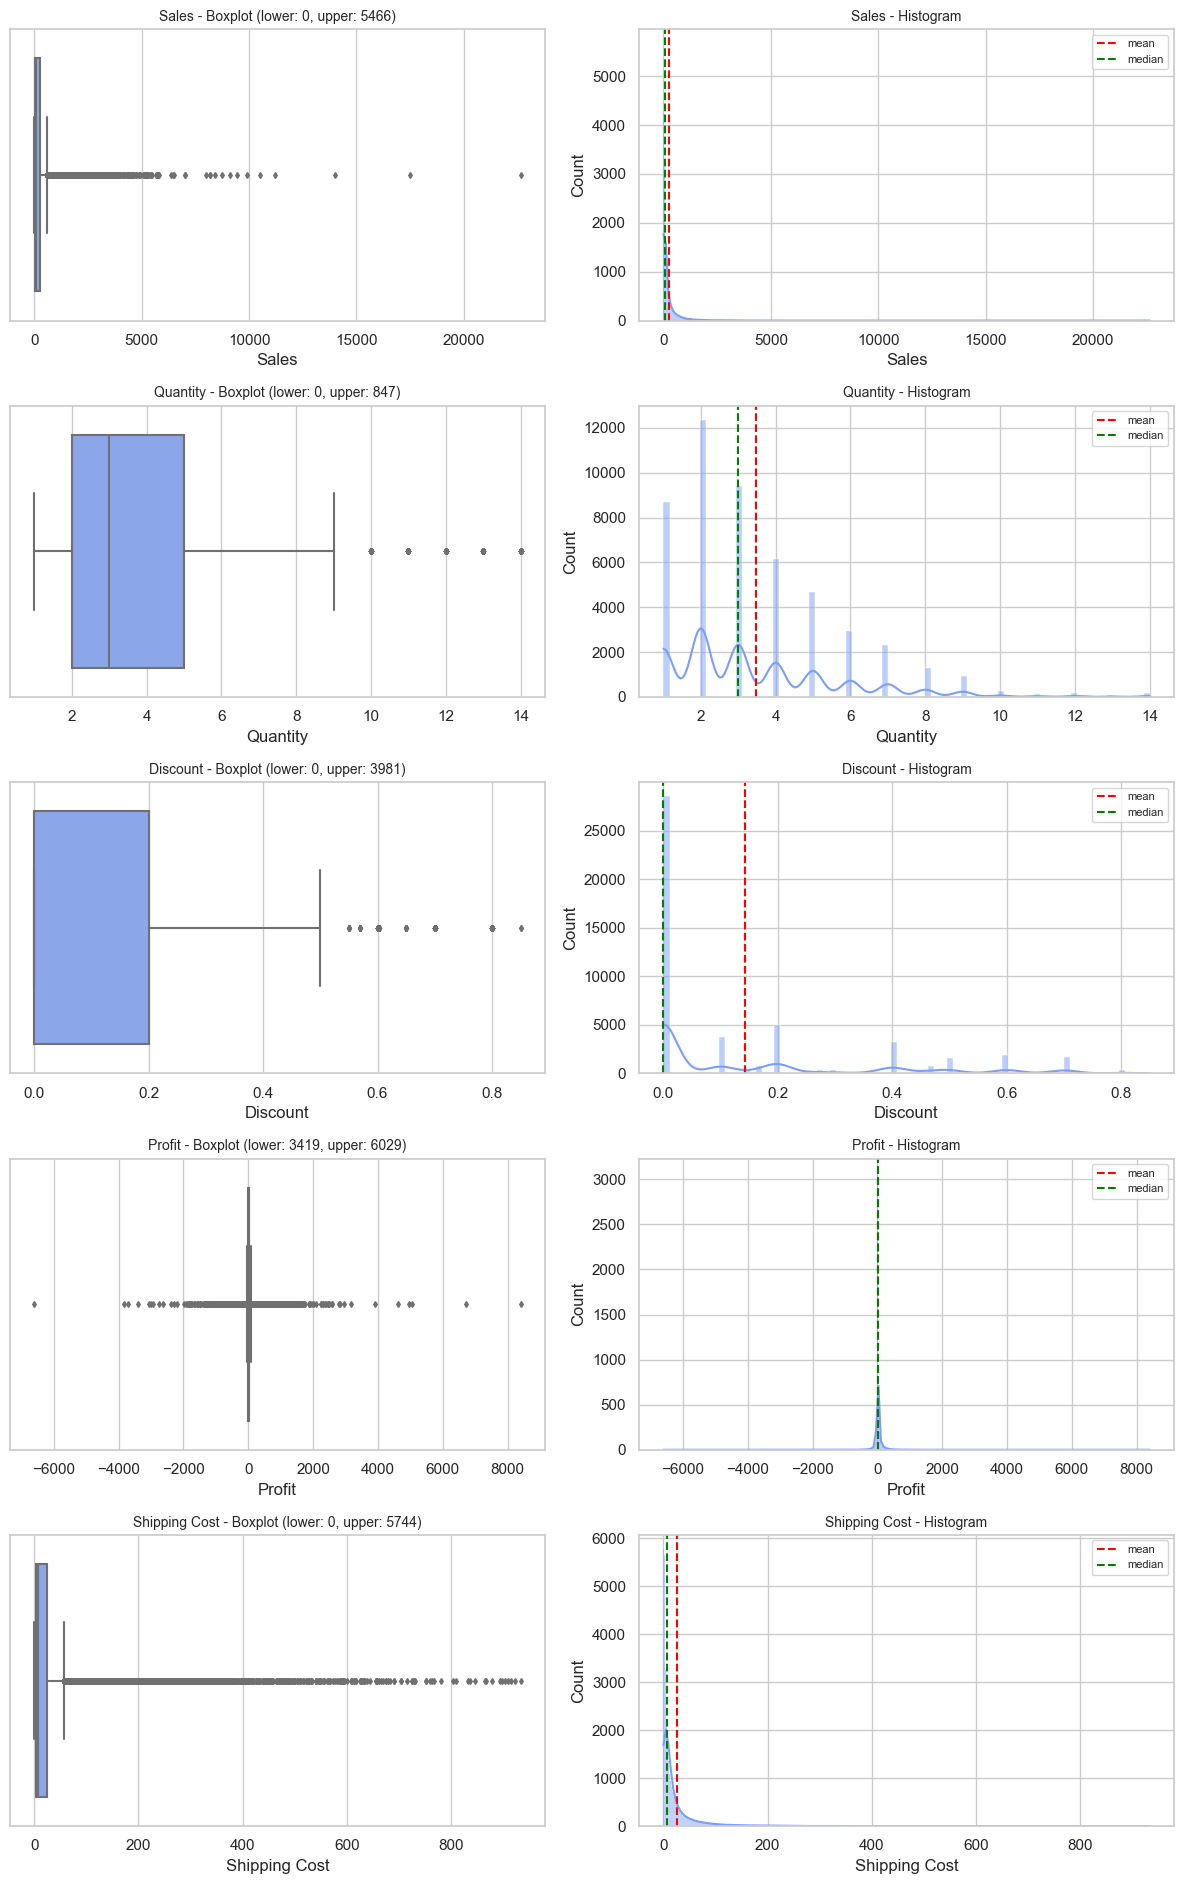

In [94]:
plot_numeric_overview(df, numeric_columns)

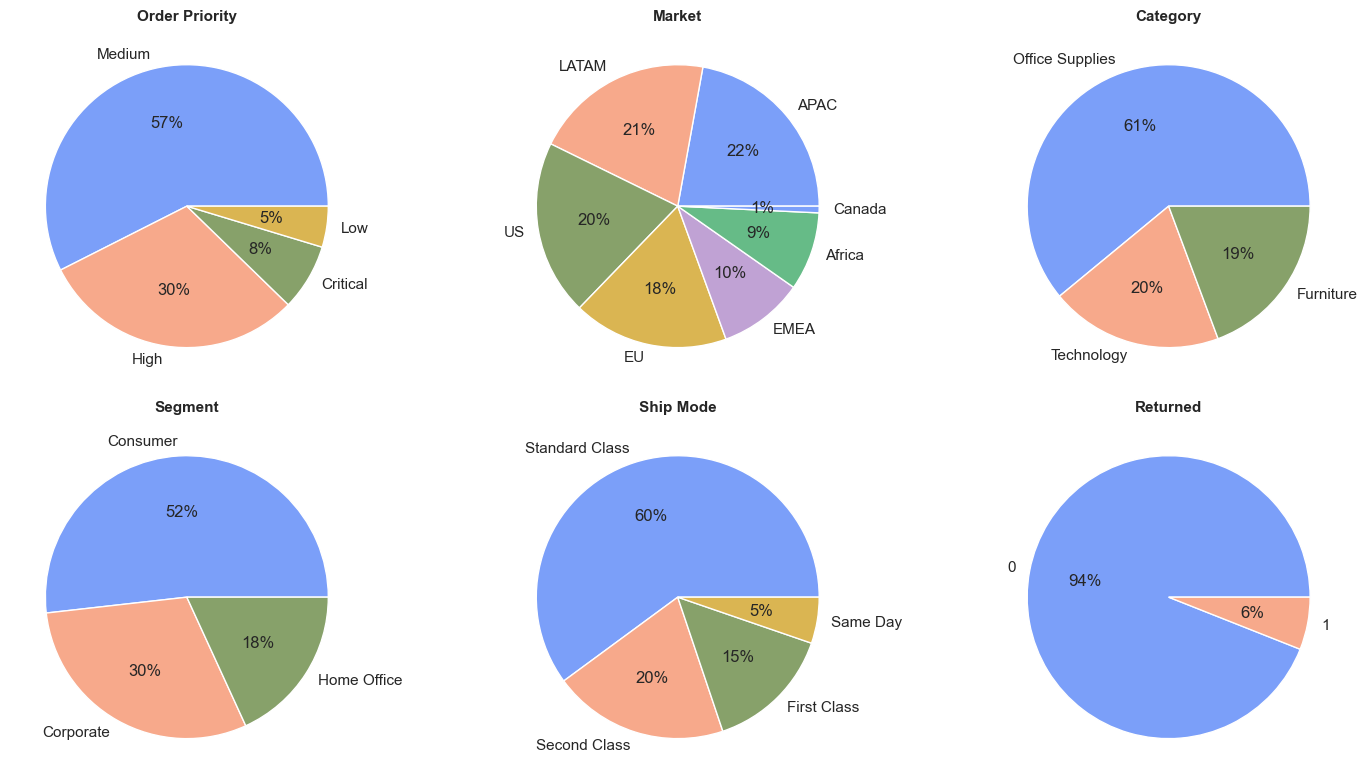

In [98]:
plot_categorical_overview(df, ["Order Priority", "Market", "Category", "Segment", "Ship Mode", "Returned"])

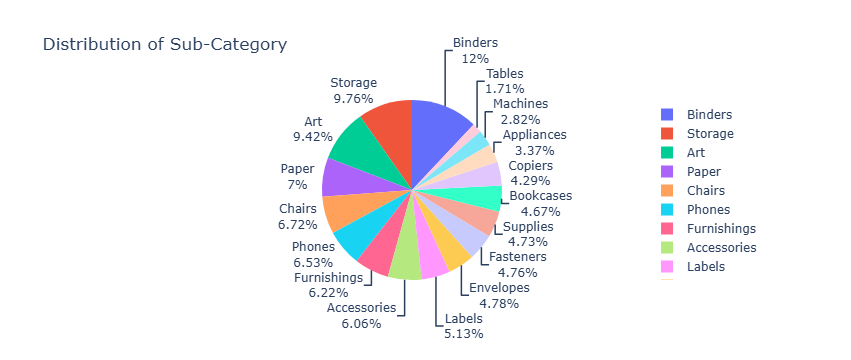

In [100]:
fig = px.pie(df, names="Sub-Category", title="Distribution of Sub-Category")
fig.update_traces(textinfo="percent+label")
fig.show()

## Correlation Overview

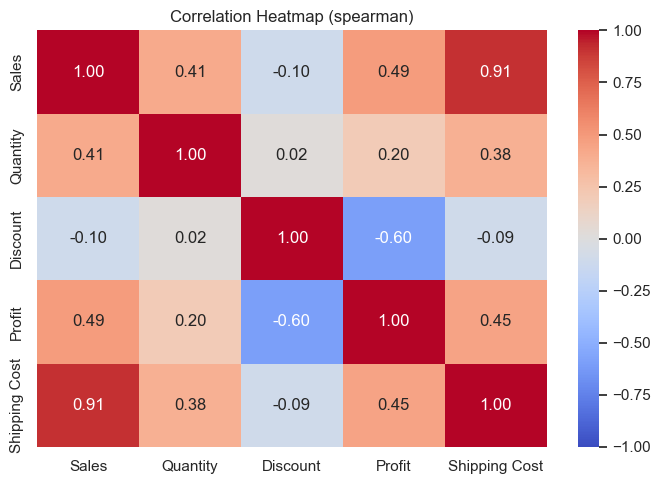

In [104]:
corr_heatmap(df[numeric_columns], method="spearman")

**Initial observation:** at first glance, the correlation between `Discount` and `Quantity` looks very weak. That's an early clue that we'll follow up on with a formal statistical test in the next section.

# EDA

In [236]:
def numeric_vs_categorical(data, col_1, col_2, alpha=0.05):
    categories = sorted(data[col_2].dropna().unique())
    X1 = data.loc[data[col_2] == categories[0], col_1].replace([np.inf, -np.inf], np.nan).dropna()
    X2 = data.loc[data[col_2] == categories[1], col_1].replace([np.inf, -np.inf], np.nan).dropna()

    shapiro_p0 = stats.shapiro(X1.sample(min(len(X1), 5000), random_state=42)).pvalue
    shapiro_p1 = stats.shapiro(X2.sample(min(len(X2), 5000), random_state=42)).pvalue
    print(f"Shapiro group '{categories[0]}': p = {shapiro_p0:.4g}")
    print(f"Shapiro group '{categories[1]}': p = {shapiro_p1:.4g}")

    lev_stat, lev_p = stats.levene(X1, X2, center="median")
    print(f"Levene (equal variance) p = {lev_p:.4g}")

    if shapiro_p0 > alpha and shapiro_p1 > alpha:
        t, p = stats.ttest_ind(X1, X2, equal_var=(lev_p > alpha))
        test_used = "t-test"
        print("Normal distribution -> t-test")
        print(f"t = {t:.4f}, p = {p:.4g}")
        effect = (X1.mean() - X2.mean()) / np.sqrt((X1.std()**2 + X2.std()**2) / 2)
        print(f"Cohen's d = {effect:.4f}")
    else:
        u, p = stats.mannwhitneyu(X1, X2, alternative="two-sided")
        test_used = "Mann-Whitney U"
        print("Not normal -> Mann-Whitney U")
        print(f"U = {u:.1f}, p = {p:.4g}")
        n1, n2 = len(X1), len(X2)
        effect = 1 - (2 * u) / (n1 * n2)
        print(f"Rank-biserial correlation (effect size) = {effect:.4f}")

    print()
    print(f"{categories[0]}: n={len(X1)}, mean={X1.mean():.4f}, median={X1.median():.4f}")
    print(f"{categories[1]}: n={len(X2)}, mean={X2.mean():.4f}, median={X2.median():.4f}")

    result = "Significant" if p < alpha else "Not Significant"
    print()
    print("Result:", result, f"(test used: {test_used})")

    return p, effect, test_used

In [ ]:
def numeric_vs_categorical(data, col_1, col_2, alpha=0.05):

    numeric_vs_categorical_plot(data, col_1, col_2)
    
    categories = data[col_2].dropna().unique()
    X1 = data.loc[data[col_2] == categories[0], col_1].dropna()
    X2 = data.loc[data[col_2] == categories[1], col_1].dropna()

    normal_p0 = stats.normaltest(X1).pvalue
    normal_p1 = stats.normaltest(X2).pvalue
    print(f"Normal test group '{categories[0]}': p = {normal_p0:.4g}")
    print(f"Normal test group '{categories[1]}': p = {normal_p1:.4g}")

    if normal_p0 > alpha and normal_p1 > alpha:
        t, p = stats.ttest_ind(X1, X2)
        print("Normal distribution -> t-test")
        print(f"t = {t:.4f}, p = {p:.4g}")
    else:
        try:
            X1_bc, _ = stats.boxcox(X1 - X1.min() + 1)
            X2_bc, _ = stats.boxcox(X2 - X2.min() + 1)
            normal_p0_bc = stats.normaltest(X1_bc).pvalue
            normal_p1_bc = stats.normaltest(X2_bc).pvalue

            if normal_p0_bc > alpha and normal_p1_bc > alpha:
                t, p = stats.ttest_ind(X1_bc, X2_bc)
                print("Normal after Box-Cox -> t-test")
                print(f"t = {t:.4f}, p = {p:.4g}")
            else:
                u, p = stats.mannwhitneyu(X1, X2, alternative="two-sided")
                print("Not normal after Box-Cox -> Mann-Whitney U")
                print(f"U = {u:.1f}, p = {p:.4g}")
        except Exception:
            u, p = stats.mannwhitneyu(X1, X2, alternative="two-sided")
            print("Box-Cox not applicable -> Mann-Whitney U")
            print(f"U = {u:.1f}, p = {p:.4g}")

    result = "Significant" if p < alpha else "Not Significant"
    print("Result:", result)
    return p


# Hypothesis Testing — Does a discount actually drive more sales?

**Common claim:** "Stores use discounts to trick people into buying more, and end up making more profit in the end."

1. Does a discount cause a **larger quantity** of an item to be sold?
2. Does the store end up with **more profit**?

For part 1, the data is split into two groups:
- **Discounted**: items where `Discount > 0`
- **No Discount**: items where `Discount == 0`

Then the distribution of `Quantity` (units sold per order-line) is compared between these two groups.

In [212]:
df["Has_Discount"] = np.where(df["Discount"] > 0, "Discounted", "No Discount")
df["Has_Discount"] = df["Has_Discount"].astype("category")

df["Has_Discount"].value_counts()

Has_Discount
No Discount    28103
Discounted     21567
Name: count, dtype: int64

### Q1: Does discount change how many units are sold per order-line?

- **Variables:** `Has_Discount` (Discounted / No Discount), `Quantity`
- **H0:** the mean/distribution of `Quantity` is the same in both groups (discount makes no difference)
- **H1:** the distribution of `Quantity` differs between the two groups

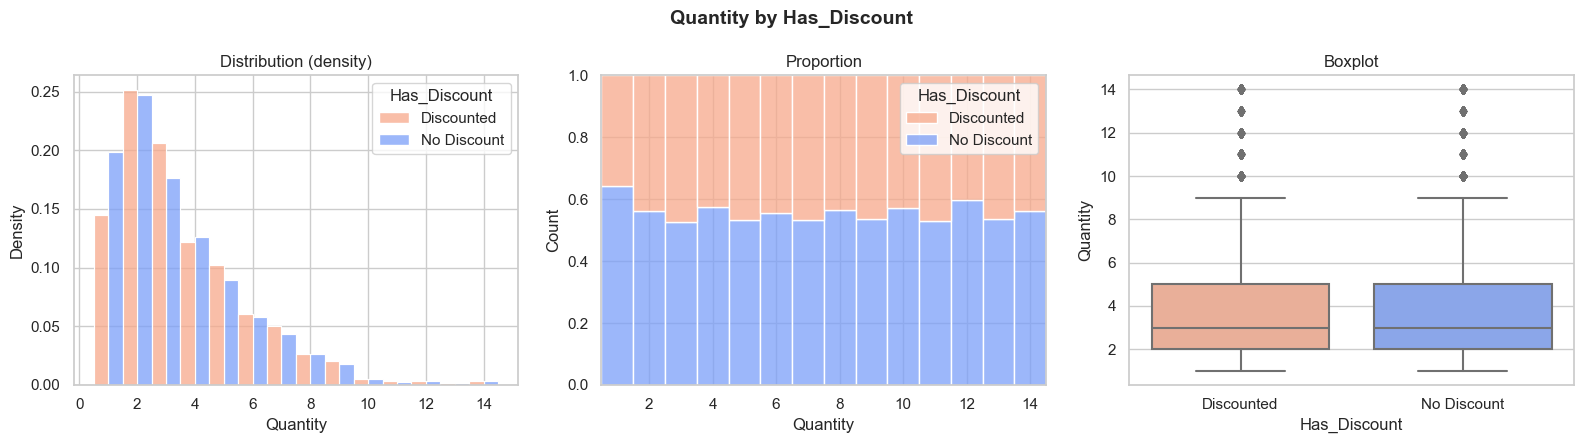

In [225]:
numeric_vs_categorical_plot(df, "Quantity", "Has_Discount")

The plots show the two distributions look very similar — both concentrated around the 1-5 range, and the boxplots nearly overlap.

In [252]:
numeric_vs_categorical(df, "Quantity", "Has_Discount")

Shapiro group 'Discounted': p = 2.774e-53
Shapiro group 'No Discount': p = 1.439e-55
Levene (equal variance) p = 0.01556
Not normal -> Mann-Whitney U
U = 320990669.5, p = 1.237e-30
Rank-biserial correlation (effect size) = -0.0592

Discounted: n=21567, mean=3.5685, median=3.0000
No Discount: n=28103, mean=3.3958, median=3.0000

Result: Significant (test used: Mann-Whitney U)


(1.2366179467933793e-30, -0.05920490327263428, 'Mann-Whitney U')

### Quantity Conclusion
- `Quantity` is not normally distributed in either group (expected — units purchased is an integer variable bounded between 1 and 14, not continuous).
- So the non-parametric **Mann-Whitney U** test was used.
- The p-value is far below 0.05, so **H0 is rejected**: the difference between the two groups is statistically significant — mean `Quantity` is a bit higher for discounted items (about 3.57 vs 3.40).


### Does the store end up with more profit?

The main question is answered above, but to fully address the original claim ("end up making more profit in the end"), the same comparison is run on `Profit`.

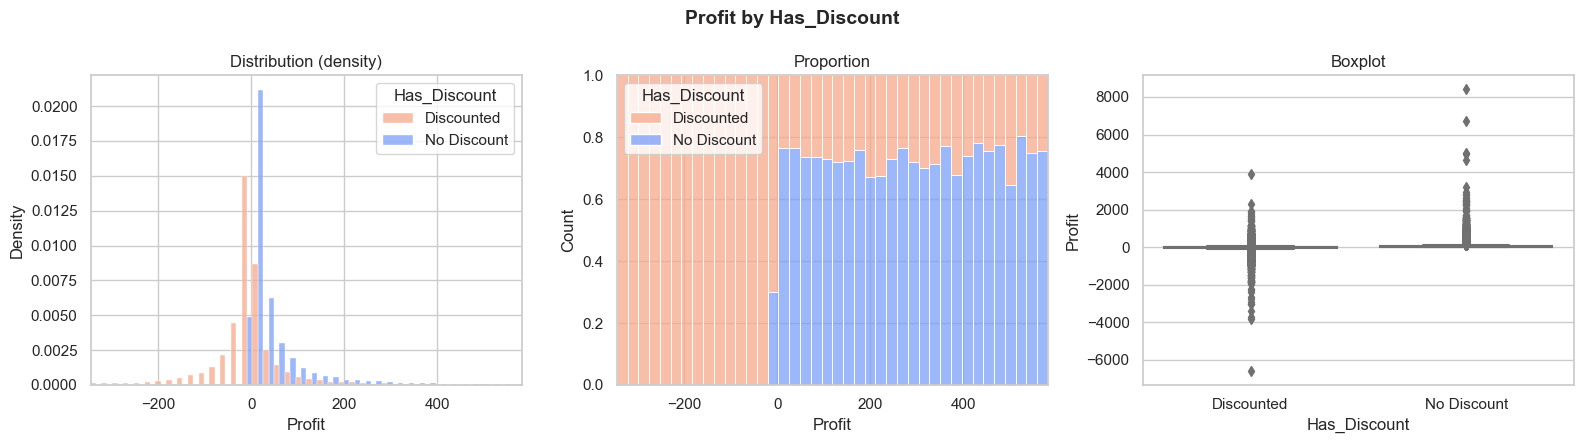

In [246]:
numeric_vs_categorical_plot(df, "Profit", "Has_Discount")

In [263]:
numeric_vs_categorical(df, "Profit", "Has_Discount")

Shapiro group 'Discounted': p = 8.679e-81
Shapiro group 'No Discount': p = 1.252e-85
Levene (equal variance) p = 1.373e-21
Not normal -> Mann-Whitney U
U = 131882626.0, p = 0
Rank-biserial correlation (effect size) = 0.5648

Discounted: n=21567, mean=-13.7843, median=-2.7000
No Discount: n=28103, mean=60.7597, median=17.6673

Result: Significant (test used: Mann-Whitney U)


(0.0, 0.5648137550749868, 'Mann-Whitney U')

In [265]:
df["Profit_Margin"] = df["Profit"] / df["Sales"]

margin_summary = df.groupby("Has_Discount", observed=True)["Profit_Margin"].agg(["mean", "median"])
margin_summary

,mean,median
Has_Discount,,
Discounted,-0.234155,-0.055851
No Discount,0.265464,0.270000


In [267]:
numeric_vs_categorical(df, "Profit_Margin", "Has_Discount")

Shapiro group 'Discounted': p = 1.161e-54
Shapiro group 'No Discount': p = 9.256e-38
Levene (equal variance) p = 0
Not normal -> Mann-Whitney U
U = 102282142.0, p = 0
Rank-biserial correlation (effect size) = 0.6625

Discounted: n=21567, mean=-0.2342, median=-0.0559
No Discount: n=28103, mean=0.2655, median=0.2700

Result: Significant (test used: Mann-Whitney U)


(0.0, 0.6624894222240693, 'Mann-Whitney U')

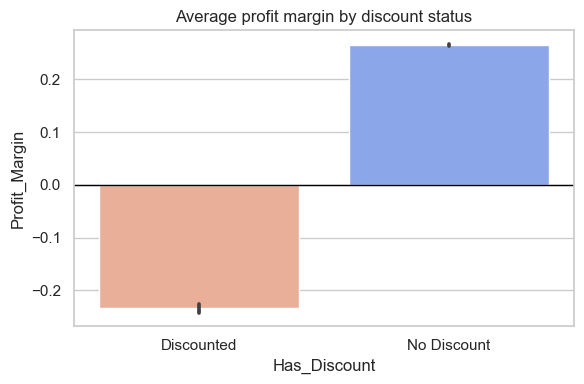

In [126]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="Has_Discount", y="Profit_Margin",
            palette=TARGET_PALETTE, estimator=np.mean, errorbar=("ci", 95))
plt.axhline(0, color="black", linewidth=1)
plt.title("Average profit margin by discount status")
plt.tight_layout()
plt.show()

### Profit Conclusion

The difference in `Profit` is also statistically significant, but in the opposite direction from the common belief: **average profit margin is negative for discounted items, while it's positive for non-discounted items.** In other words, when a discount is applied, the store loses money on that item on average, rather than making mor.


## Final Conclusion
Discounts do cause a small increase in sales quantity, but it's far smaller than the popular belief suggests, and more importantly, that tiny quantity gain doesn't make up for the sharp drop in profit margin. In this dataset, discounts look more like a marketing cost (or a reaction to market/inventory conditions) than a guaranteed profitable strategy.

**Limitations:**
- This is a *correlational* analysis, not a causal one — discounts may have been applied more often to products that were already slower-selling or cheaper to begin with (confounding).
- The data doesn't include information on *why* a discount was given (seasonal, excess inventory, competitive pricing, etc.), which could sharpen the interpretation.
